<a href="https://colab.research.google.com/github/ciril7/AI-ML-Internship/blob/main/Day%205/Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import zipfile
import os

zip_path = "/content/archive (21).zip"
extract_path = "/content/brain_tumor"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [7]:
dataset_path = "/content/brain_tumor/brain_tumor_dataset"

X = []
y = []

IMG_SIZE = 128

classes = {
    "no": 0,
    "yes": 1
}

for label in classes:

    folder = os.path.join(dataset_path, label)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize
        gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))

        # Normalize
        gray = gray / 255.0

        # HOG Feature Extraction
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        X.append(features)
        y.append(classes[label])

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (253, 8100)
Labels Shape: (253,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 202
Testing Samples: 51


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9215686274509803


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8823529411764706


In [12]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.8431372549019608


In [13]:
print("Model Performance")
print("-"*30)

print("SVM Accuracy          :", svm_acc)
print("Random Forest Accuracy:", rf_acc)
print("KNN Accuracy          :", knn_acc)

Model Performance
------------------------------
SVM Accuracy          : 0.9215686274509803
Random Forest Accuracy: 0.8823529411764706
KNN Accuracy          : 0.8431372549019608


In [14]:
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       1.00      0.80      0.89        20
           1       0.89      1.00      0.94        31

    accuracy                           0.92        51
   macro avg       0.94      0.90      0.91        51
weighted avg       0.93      0.92      0.92        51



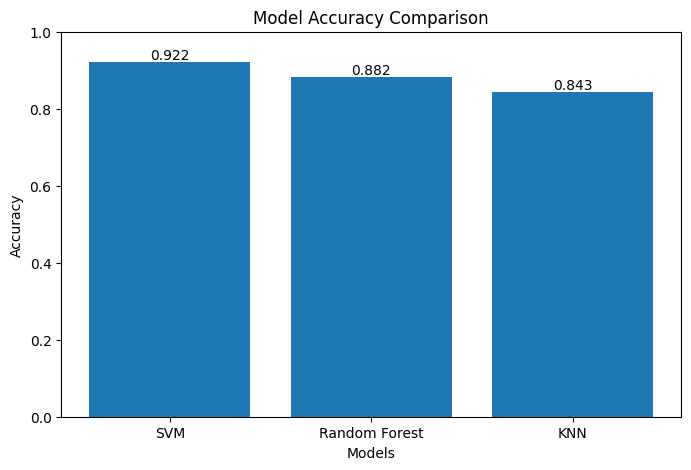

In [15]:
import matplotlib.pyplot as plt

models = ['SVM', 'Random Forest', 'KNN']
accuracies = [svm_acc, rf_acc, knn_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.show()

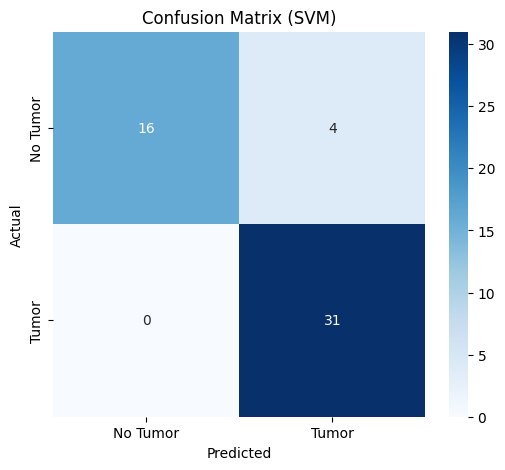

In [16]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Tumor","Tumor"],
    yticklabels=["No Tumor","Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")

plt.show()

In [17]:
def predict_brain_tumor(image_path):

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (128,128))

    gray = gray / 255.0

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    features = scaler.transform([features])

    prediction = svm_model.predict(features)[0]

    if prediction == 1:
        print("Brain Tumor Detected")
    else:
        print("No Brain Tumor")

In [18]:
predict_brain_tumor(
    "/content/brain_tumor/brain_tumor_dataset/yes/Y1.jpg"
)

Brain Tumor Detected


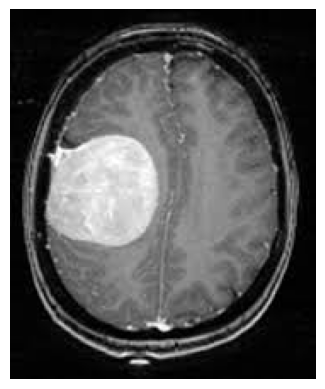

Prediction: 1
🧠 Brain Tumor Detected


In [19]:
import cv2
import numpy as np
from skimage.feature import hog
import matplotlib.pyplot as plt

# Image path
image_path = "/content/brain_tumor/brain_tumor_dataset/yes/Y1.jpg"

# Read image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
else:
    # Display image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize (same as training)
    gray = cv2.resize(gray, (128, 128))

    # Normalize
    gray = gray / 255.0

    # Extract HOG features
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    # Scale features
    features = scaler.transform([features])

    # Prediction
    prediction = svm_model.predict(features)

    print("Prediction:", prediction[0])

    if prediction[0] == 1:
        print("🧠 Brain Tumor Detected")
    else:
        print("✅ No Brain Tumor Detected")


Image: /content/brain_tumor/brain_tumor_dataset/yes/Y13.jpg
🧠 Brain Tumor Detected
Prediction: 1

Image: /content/brain_tumor/brain_tumor_dataset/no/N22.jpg
❌ Image not found!

Image: /content/brain_tumor/brain_tumor_dataset/yes/Y67.jpg
❌ Image not found!

Image: /content/brain_tumor/brain_tumor_dataset/no/no18 .jpg
❌ Image not found!


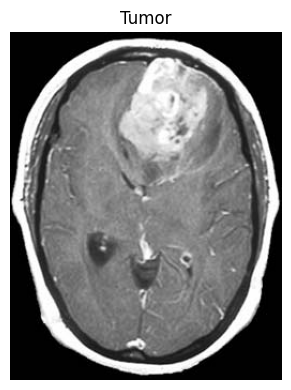

In [21]:
import cv2
import numpy as np
from skimage.feature import hog
import matplotlib.pyplot as plt

# List of image paths
image_paths = [
    "/content/brain_tumor/brain_tumor_dataset/yes/Y13.jpg",
    "/content/brain_tumor/brain_tumor_dataset/no/N22.jpg",
    "/content/brain_tumor/brain_tumor_dataset/yes/Y67.jpg",
    "/content/brain_tumor/brain_tumor_dataset/no/no18 .jpg"
]

plt.figure(figsize=(16,4))

for i, image_path in enumerate(image_paths):

    print("\n" + "="*50)
    print("Image:", image_path)

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Image not found!")
        continue

    # Preprocessing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    gray = gray / 255.0

    # HOG Feature Extraction
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    # Scaling
    features = scaler.transform([features])

    # Prediction
    pred = svm_model.predict(features)[0]

    # Label
    if pred == 1:
        label = "Tumor"
        print("🧠 Brain Tumor Detected")
    else:
        label = "No Tumor"
        print("✅ No Brain Tumor Detected")

    print("Prediction:", pred)

    # Display image in subplot
    plt.subplot(1, len(image_paths), i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()